# Türkçe Tıbbi Vektör Arama ve Threshold Analizi

Bu notebook, `umutertugrul/turkish-medical-articles` veri setinden 500
dermatoloji makalesi seçerek mixed chunking, yerel embedding, ChromaDB vektör
arama ve cevaplanabilirlik eşiği analizini baştan sona yeniden üretir.

Ana deney üretken LLM gerektirmez. En sondaki Qwen bölümü opsiyoneldir ve
varsayılan olarak kapalıdır.

> Eğitim amaçlıdır; tanı, tedavi veya kişiselleştirilmiş tıbbi öneri vermez.

## Deney tasarımı

1. Gated Hugging Face veri setini indir.
2. `Dermatoloji` branşını filtrele, kalite kontrollerinden geçir ve `seed=42`
   ile 500 makale seç.
3. Paragraf → cümle → token öncelikli 512 token + 64 overlap chunking uygula.
4. `magibu/embeddingmagibu-200m` ile 768 boyutlu L2-normalized vektör üret.
5. Vektörleri cosine ChromaDB koleksiyonunda sakla.
6. Ekstra 20 soruluk kalibrasyon setiyle threshold belirle.
7. Threshold'u değiştirmeden bağımsız 20 pozitif + 10 negatif soruda değerlendir.

Kalibrasyon/test ayrımı threshold'un test verisine aşırı uyumunu önler.

## 0. Ortam kurulumu

Notebook, repo kökünden veya `notebooks/` klasöründen açılabilir. Kurulum hücresi
önce gerçek proje kökünü bulur, sonra bağımlılıkları **bu notebook'un aktif
Python kernelına** kurar. Terminaldeki `pip` ile kernelın Python'u farklı
olabileceği için kurulum `sys.executable -m pip` üzerinden yapılır.

Proje Python 3.10+ gerektirir. VS Code'da sağ üstte görünen kernel daha eskiyse
önce Python 3.10 veya daha yeni bir kernel seçilmelidir. Colab'ın güncel Python
sürümü doğrudan desteklenir.

In [1]:
from pathlib import Path
import importlib.util
import subprocess
import sys

IN_COLAB = "google.colab" in sys.modules


def find_project_root(start: Path) -> Path:
    # Find the repository root from either the root or notebooks directory.
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").is_file() and (candidate / "src").is_dir():
            return candidate
    raise FileNotFoundError(
        "Proje kökü bulunamadı. Notebook'u klonlanmış "
        "turkish-medical-vector-search reposunun içinden açın."
    )


PROJECT_ROOT = find_project_root(Path.cwd())

if sys.version_info < (3, 10):
    raise RuntimeError(
        f"Bu proje Python 3.10+ gerektirir; aktif kernel {sys.version.split()[0]}. "
        "VS Code sağ üst menüsünden Python 3.10 veya daha yeni bir kernel seçin."
    )

# Temiz bir kernelda gerekli temel modüllerden biri yoksa kurulum otomatik yapılır.
REQUIRED_MODULES = ("yaml", "pydantic", "chromadb", "datasets", "sentence_transformers")
INSTALL_DEPENDENCIES = any(importlib.util.find_spec(name) is None for name in REQUIRED_MODULES)

if INSTALL_DEPENDENCIES:
    print("Notebook bağımlılıkları aktif kernela kuruluyor:", sys.executable)
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "--upgrade", "pip", "setuptools", "wheel"],
        check=True,
    )
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-e", f"{PROJECT_ROOT}[notebook]"],
        check=True,
    )
else:
    print("Gerekli bağımlılıklar aktif kernelda zaten kurulu.")

print("Python:", sys.executable)
print("Python sürümü:", sys.version.split()[0])
print("Proje kökü:", PROJECT_ROOT)

Gerekli bağımlılıklar aktif kernelda zaten kurulu.
Python: /opt/homebrew/opt/python@3.11/bin/python3.11
Python sürümü: 3.11.15
Proje kökü: /Users/berkbirkan/magibu-çalışmalar/turkish-medical-vector-search


## 1. Yapılandırmayı yükleme

Tüm kritik kararlar `configs/default.yaml` içinde tutulur. Bilinmeyen alanlar
Pydantic tarafından reddedilir; böylece yazım hatalı bir config sessizce
çalışmaz.

In [2]:
src_path = str(PROJECT_ROOT / "src")
if src_path not in sys.path:
    sys.path.insert(0, src_path)

from turkish_medical_vector_search.config import load_config

config_path = PROJECT_ROOT / "configs" / "default.yaml"
assert config_path.is_file(), f"Config bulunamadı: {config_path}"
config = load_config(config_path)
print(config.model_dump_json(indent=2))

{
  "project": {
    "seed": 42
  },
  "dataset": {
    "repo_id": "umutertugrul/turkish-medical-articles",
    "split": "train",
    "branch_query": "Dermatoloji",
    "sample_size": 500,
    "min_text_length": 200
  },
  "chunking": {
    "target_tokens": 512,
    "overlap_tokens": 64,
    "min_chunk_tokens": 80,
    "separators": [
      "\n\n",
      "\n",
      ". ",
      " "
    ]
  },
  "embedding": {
    "model_id": "magibu/embeddingmagibu-200m",
    "dimension": 768,
    "normalize": true,
    "batch_size": 32
  },
  "vector_store": {
    "provider": "chromadb",
    "collection_name": "turkish_dermatology_articles",
    "distance_metric": "cosine",
    "persist_directory": "data/chroma"
  },
  "retrieval": {
    "top_k": 5,
    "threshold": 0.424,
    "abstention_message": "Bu sorunun cevabı dokümanlarımda yer almamaktadır."
  },
  "benchmark": {
    "calibration_positive": 10,
    "calibration_negative": 10,
    "test_positive": 20,
    "test_negative": 10
  },
  "optional_l

## 2. Hugging Face kimlik doğrulaması

Kaynak veri gated'dır. Önce veri seti sayfasındaki koşulları kabul edin. Token'ı
notebook hücresine yazmayın. Colab Secrets içindeki `HF_TOKEN`, standart Hugging
Face oturumu veya aşağıdaki güvenli `notebook_login()` arayüzü kullanılabilir.

In [3]:
from huggingface_hub import HfApi, notebook_login

try:
    account = HfApi().whoami()["name"]
    print("Hugging Face account:", account)
except Exception:
    print("Oturum bulunamadı. Açılan güvenli alana token girin.")
    notebook_login()

/opt/homebrew/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Hugging Face account: berkbirkan


## 3. Kaynak veriyi indirme

Tam Parquet yaklaşık 107 MB'dir ve `data/raw/` altında tutulur. Ham veri Git'e
eklenmez. Hücre yeniden çalıştırıldığında Hugging Face cache kullanılır.

In [4]:
subprocess.run(
    [sys.executable, "scripts/download_source.py"],
    cwd=PROJECT_ROOT,
    check=True,
)

Downloaded umutertugrul/turkish-medical-articles/doktorsitesi_articles.parquet to /Users/berkbirkan/magibu-çalışmalar/turkish-medical-vector-search/data/raw/doktorsitesi_articles.parquet


CompletedProcess(args=['/opt/homebrew/opt/python@3.11/bin/python3.11', 'scripts/download_source.py'], returncode=0)

## 4. Dermatoloji makalelerini seçme

Zorunlu alanı eksik, 200 karakterden kısa, yinelenen URL/metin içeren kayıtlar
elenir. Kalan kayıtlar URL'ye göre sıralanıp `seed=42` ile örneklenir. Kaynak
satır sonları, sonraki mixed chunking aşaması için korunur.

In [5]:
subprocess.run([sys.executable, "scripts/select_articles.py"], cwd=PROJECT_ROOT, check=True)

import json
selection = json.loads(
    (PROJECT_ROOT / "reports/metrics/selection_summary.json").read_text(encoding="utf-8")
)
selection

Selected 500 of 1056 eligible articles
Output: /Users/berkbirkan/magibu-çalışmalar/turkish-medical-vector-search/data/interim/selected_articles.parquet
Report: /Users/berkbirkan/magibu-çalışmalar/turkish-medical-vector-search/reports/metrics/selection_summary.json


{'source_repo': 'umutertugrul/turkish-medical-articles',
 'source_file': 'doktorsitesi_articles.parquet',
 'selection': {'source_rows': 41804,
  'branch_rows': 1061,
  'rejected_missing_required': 3,
  'rejected_short_text': 1,
  'rejected_duplicate_url': 0,
  'rejected_duplicate_text': 1,
  'eligible_rows': 1056,
  'selected_rows': 500,
  'branch_label': 'Dermatoloji',
  'sample_size': 500,
  'seed': 42,
  'min_text_length': 200}}

## 5. Mixed chunking

Kısa paragraflar korunur. Uzun paragraflar önce cümle, gerekirse token sınırından
bölünür. Başlık her chunk'a eklenir ve 512 token bütçesine dahildir. 64 token
overlap, sınırdaki bağlam kaybını azaltır. Kısa son parçalar kontrollü overlap
genişletmesiyle en az 80 tokena tamamlanır.

In [6]:
subprocess.run([sys.executable, "scripts/chunk_articles.py"], cwd=PROJECT_ROOT, check=True)

chunking = json.loads(
    (PROJECT_ROOT / "reports/metrics/chunking_summary.json").read_text(encoding="utf-8")
)
chunking

Created 1019 chunks from 500 articles
Output: /Users/berkbirkan/magibu-çalışmalar/turkish-medical-vector-search/data/processed/chunks.parquet
Report: /Users/berkbirkan/magibu-çalışmalar/turkish-medical-vector-search/reports/metrics/chunking_summary.json


{'article_count': 500,
 'chunk_count': 1019,
 'embedding_model': 'magibu/embeddingmagibu-200m',
 'tokenizer_patch': 'not_applied_custom_split_pretokenizer',
 'target_tokens': 512,
 'overlap_tokens': 64,
 'min_chunk_tokens': 80,
 'token_count': {'min': 83,
  'median': 428,
  'mean': 385.0186457311089,
  'max': 512},
 'chunks_per_article': {'min': 1, 'median': 2.0, 'mean': 2.038, 'max': 28},
 'articles_without_chunks': 0,
 'chunks_over_target': 0}

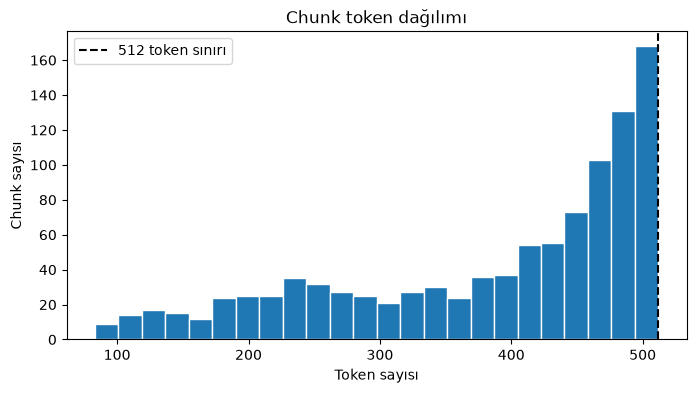

In [7]:
import matplotlib.pyplot as plt
import pyarrow.parquet as pq

chunks = pq.read_table(PROJECT_ROOT / "data/processed/chunks.parquet")
token_counts = chunks.column("token_count").to_pylist()
plt.figure(figsize=(8, 4))
plt.hist(token_counts, bins=24, edgecolor="white")
plt.axvline(512, color="black", linestyle="--", label="512 token sınırı")
plt.xlabel("Token sayısı")
plt.ylabel("Chunk sayısı")
plt.title("Chunk token dağılımı")
plt.legend()
plt.show()

## 6. Yerel embedding üretimi

EmbeddingMagibu Türkçe odaklı, yaklaşık 200M parametreli, 8.192 token context ve
768 boyutlu bir modeldir. Dokümanlar `encode_document`, sorular `encode_query`
ile kodlanır. Çıktılar L2 normalize edilir. Batch checkpoint'leri kesintide
hesaplamayı korur.

In [8]:
subprocess.run([sys.executable, "scripts/embed_chunks.py"], cwd=PROJECT_ROOT, check=True)

embedding = json.loads(
    (PROJECT_ROOT / "reports/metrics/embedding_summary.json").read_text(encoding="utf-8")
)
embedding

Loading weights: 100%|██████████| 314/314 [00:00<00:00, 6046.94it/s]


Embedded chunks 0:32
Embedded chunks 32:64
Embedded chunks 64:96
Embedded chunks 96:128
Embedded chunks 128:160
Embedded chunks 160:192
Embedded chunks 192:224
Embedded chunks 224:256
Embedded chunks 256:288
Embedded chunks 288:320
Embedded chunks 320:352
Embedded chunks 352:384
Embedded chunks 384:416
Embedded chunks 416:448
Embedded chunks 448:480
Embedded chunks 480:512
Embedded chunks 512:544
Embedded chunks 544:576
Embedded chunks 576:608
Embedded chunks 608:640
Embedded chunks 640:672
Embedded chunks 672:704
Embedded chunks 704:736
Embedded chunks 736:768
Embedded chunks 768:800
Embedded chunks 800:832
Embedded chunks 832:864
Embedded chunks 864:896
Embedded chunks 896:928
Embedded chunks 928:960
Embedded chunks 960:992
Embedded chunks 992:1019
Wrote 1019 vectors to /Users/berkbirkan/magibu-çalışmalar/turkish-medical-vector-search/data/processed/chunks_with_vectors.parquet


{'chunk_count': 1019,
 'model_id': 'magibu/embeddingmagibu-200m',
 'dimension': 768,
 'dtype': 'float32',
 'normalize': True,
 'batch_size': 32,
 'source_sha256': '7556569457d2f96c40f0cff0ca7e94ed988f38e800c3588046c2a8f97b40ffba',
 'checkpoint_fingerprint': '18a35bac2c4a327e531d04978d6f796ae4f516f55f76202bb557330a081f9dc0',
 'tokenizer_patch': 'not_applied_custom_split_pretokenizer',
 'norm_min': 0.9999998807907104,
 'norm_mean': 1.0,
 'norm_max': 1.0000001192092896,
 'finite_values': True}

In [9]:
embedded = pq.read_table(PROJECT_ROOT / "data/processed/chunks_with_vectors.parquet")
print(embedded.schema)
assert embedded.num_rows == 1019
assert len(embedded.column("chunk_vector")[0].as_py()) == 768

chunk_id: string
parent_id: string
url: string
title: string
branch: string
chunk_index: int64
token_count: int64
chunk_text: string
chunk_vector: fixed_size_list<element: float>[768]
  child 0, element: float
embedding_model: string


## 7. ChromaDB cosine koleksiyonu

Chroma cosine distance döndürür. Bu projede kullanıcıya gösterilen ve threshold
ile karşılaştırılan değer `cosine_similarity = 1 - distance` formülüyle elde
edilir.

In [10]:
subprocess.run([sys.executable, "scripts/build_chroma.py"], cwd=PROJECT_ROOT, check=True)

Collection: turkish_dermatology_articles
Records: 1019


CompletedProcess(args=['/opt/homebrew/opt/python@3.11/bin/python3.11', 'scripts/build_chroma.py'], returncode=0)

## 8. Örnek semantic search

In [11]:
import chromadb

from turkish_medical_vector_search.embeddings.local import LocalSentenceEmbedder
from turkish_medical_vector_search.retrieval.search import search_collection

question = "Cildimizi kışa hazırlamak için neler yapmalıyız?"
embedder = LocalSentenceEmbedder(
    config.embedding.model_id,
    expected_dimension=config.embedding.dimension,
    normalize=config.embedding.normalize,
)
query_vector = embedder.encode_queries([question])[0].tolist()
client = chromadb.PersistentClient(
    path=str(PROJECT_ROOT / config.vector_store.persist_directory)
)
collection = client.get_collection(config.vector_store.collection_name)
result = search_collection(
    collection,
    question=question,
    query_vector=query_vector,
    top_k=3,
    threshold=config.retrieval.threshold,
    abstention_message=config.retrieval.abstention_message,
)

print("Answerable:", result.answerable)
print(result.message or "Threshold geçildi.")
for rank, hit in enumerate(result.hits, start=1):
    print(f"#{rank} similarity={hit.similarity:.4f} | {hit.metadata['title']}")
    print(hit.metadata["url"])

Loading weights: 100%|██████████| 314/314 [00:00<00:00, 5905.38it/s]


Answerable: True
Threshold geçildi.
#1 similarity=0.7792 | Kışın cilt bakımı ve tedavisi
https://www.doktorsitesi.com/blog/makale/kisin-cilt-bakimi-ve-tedavisi
#2 similarity=0.7430 | Cildimizi kışa hazırlamak için yapmamız gereken 10 şey nedir ?
https://www.doktorsitesi.com/blog/makale/cildimizi-kisa-hazirlamak-icin-yapmamiz-gereken-10-sey-nedir
#3 similarity=0.7335 | Kışın cilt bakımı ve tedavisi
https://www.doktorsitesi.com/blog/makale/kisin-cilt-bakimi-ve-tedavisi


## 9. Benchmark hazırlama

Pozitif sorular elle doğrulanmış evidence chunk ve URL içerir. Negatif soruların
ayırt edici terimleri corpus'un tamamında sıfır geçişle doğrulanır. Kalibrasyon
20, bağımsız test 30 sorudur.

In [14]:
subprocess.run([sys.executable, "scripts/prepare_benchmark.py"], cwd=PROJECT_ROOT, check=True)

validation = json.loads(
    (PROJECT_ROOT / "reports/metrics/benchmark_validation.json").read_text(encoding="utf-8")
)
validation

Calibration questions: 20
Test questions: 30
Report: /Users/berkbirkan/magibu-çalışmalar/turkish-medical-vector-search/reports/metrics/benchmark_validation.json


{'corpus_chunks': 1019,
 'total_questions': 50,
 'calibration': {'positive': 10, 'negative': 10},
 'test': {'positive': 20, 'negative': 10},
 'unique_positive_evidence_chunks': 30,
 'negative_absence_checks': {'cal_neg_01': {'alvarado skoru': 0},
  'cal_neg_02': {'fev1/fvc': 0},
  'cal_neg_03': {'child-pugh': 0},
  'cal_neg_04': {'egfr': 0},
  'cal_neg_05': {'mitral kapak alanı': 0},
  'cal_neg_06': {'glasgow koma skoru': 0},
  'cal_neg_07': {'fakoemülsifikasyon': 0},
  'cal_neg_08': {'levetirasetam': 0},
  'cal_neg_09': {'total kalça protezi': 0},
  'cal_neg_10': {'bazal-bolus': 0},
  'test_neg_01': {'hipertrofik kardiyomiyopati': 0},
  'test_neg_02': {'meld skoru': 0},
  'test_neg_03': {'romberg testi': 0},
  'test_neg_04': {'inr hedefi': 0},
  'test_neg_05': {'apgar skoru': 0},
  'test_neg_06': {'karlofça antlaşması': 0},
  'test_neg_07': {'timsort': 0},
  'test_neg_08': {'olympus mons': 0},
  'test_neg_09': {'canberra': 0},
  'test_neg_10': {'heisenberg belirsizlik ilkesi': 0}}}

## 10. Threshold kalibrasyonu ve bağımsız test

Yanlış kabul maliyeti 2, yanlış ret maliyeti 1 alınır. Threshold yalnızca
kalibrasyondan seçilir. Test sonuçları threshold dondurulduktan sonra hesaplanır.

In [13]:
subprocess.run([sys.executable, "scripts/evaluate_benchmark.py"], cwd=PROJECT_ROOT, check=True)

evaluation = json.loads(
    (PROJECT_ROOT / "reports/metrics/threshold_evaluation.json").read_text(encoding="utf-8")
)
evaluation

Loading weights: 100%|██████████| 314/314 [00:00<00:00, 5746.20it/s]


{
  "model_id": "magibu/embeddingmagibu-200m",
  "top_k": 5,
  "threshold_selection": {
    "source_split": "calibration_only",
    "false_accept_cost": 2.0,
    "false_reject_cost": 1.0,
    "selected_threshold": 0.4240220785140991,
    "calibration_positive_score_min": 0.431279718875885,
    "calibration_positive_score_max": 0.7740194797515869,
    "calibration_negative_score_min": 0.22627627849578857,
    "calibration_negative_score_max": 0.41676443815231323
  },
  "calibration": {
    "classification": {
      "tp": 10,
      "fn": 0,
      "fp": 0,
      "tn": 10,
      "precision": 1.0,
      "recall": 1.0,
      "f1": 1.0,
      "accuracy": 1.0,
      "negative_rejection_rate": 1.0,
      "weighted_error_cost": 0.0
    },
    "retrieval": {
      "exact_chunk_recall@1": 0.6,
      "parent_document_recall@1": 0.7,
      "exact_chunk_recall@3": 0.8,
      "parent_document_recall@3": 0.8,
      "exact_chunk_recall@5": 0.9,
      "parent_document_recall@5": 0.9
    },
    "error_ana

{'model_id': 'magibu/embeddingmagibu-200m',
 'top_k': 5,
 'threshold_selection': {'source_split': 'calibration_only',
  'false_accept_cost': 2.0,
  'false_reject_cost': 1.0,
  'selected_threshold': 0.4240220785140991,
  'calibration_positive_score_min': 0.431279718875885,
  'calibration_positive_score_max': 0.7740194797515869,
  'calibration_negative_score_min': 0.22627627849578857,
  'calibration_negative_score_max': 0.41676443815231323},
 'calibration': {'classification': {'tp': 10,
   'fn': 0,
   'fp': 0,
   'tn': 10,
   'precision': 1.0,
   'recall': 1.0,
   'f1': 1.0,
   'accuracy': 1.0,
   'negative_rejection_rate': 1.0,
   'weighted_error_cost': 0.0},
  'retrieval': {'exact_chunk_recall@1': 0.6,
   'parent_document_recall@1': 0.7,
   'exact_chunk_recall@3': 0.8,
   'parent_document_recall@3': 0.8,
   'exact_chunk_recall@5': 0.9,
   'parent_document_recall@5': 0.9},
  'error_analysis': {'positive_score_min': 0.431279718875885,
   'positive_score_max': 0.7740194797515869,
   'nega

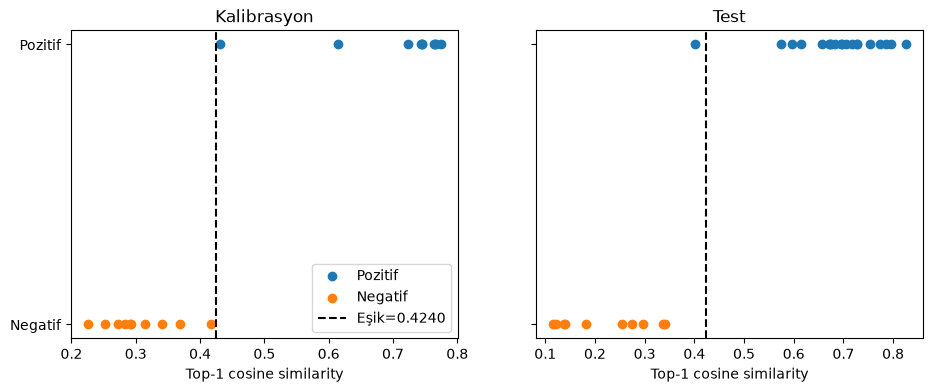

In [15]:
import csv

threshold = evaluation["threshold_selection"]["selected_threshold"]
calibration_rows = [
    json.loads(line)
    for line in (PROJECT_ROOT / "reports/metrics/calibration_results.jsonl").read_text().splitlines()
]
test_rows = [
    json.loads(line)
    for line in (PROJECT_ROOT / "reports/metrics/test_results.jsonl").read_text().splitlines()
]

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for axis, rows, title in zip(axes, [calibration_rows, test_rows], ["Kalibrasyon", "Test"]):
    pos = [row["top_similarity"] for row in rows if row["is_answerable"]]
    neg = [row["top_similarity"] for row in rows if not row["is_answerable"]]
    axis.scatter(pos, [1] * len(pos), label="Pozitif")
    axis.scatter(neg, [0] * len(neg), label="Negatif")
    axis.axvline(threshold, color="black", linestyle="--", label=f"Eşik={threshold:.4f}")
    axis.set_title(title)
    axis.set_xlabel("Top-1 cosine similarity")
    axis.set_yticks([0, 1], ["Negatif", "Pozitif"])
axes[0].legend()
plt.show()

## 11. Sonuçların yorumu

Bağımsız testte answerability precision 1,00, recall 0,95 ve F1 0,9744'tür.
Exact chunk Recall@1 ve parent Recall@1 0,50'dir. Bazı sorularda aynı bilgiyi
taşıyan alternatif makalelerin beklenen kanıtın önüne geçmesi bu farkı açıklar.
Bu nedenle threshold başarısı, exact evidence ranking başarısıyla
karıştırılmamalıdır.

## 12. Hugging Face Dataset dışa aktarma

Yükleme varsayılan olarak kapalıdır. Repo kimliğini kendinize göre ayarlayıp
yalnızca açık onayla çalıştırın. Hugging Face tokenı koda yazılmaz.

In [16]:
PUSH_TO_HUB = False
HF_DATASET_REPO = "berkbirkan/turkish-dermatology-rag-dataset"

subprocess.run([sys.executable, "scripts/export_hf_dataset.py"], cwd=PROJECT_ROOT, check=True)

if PUSH_TO_HUB:
    from datasets import Dataset
    dataset = Dataset.from_parquet(PROJECT_ROOT / "hf_dataset/data/train.parquet")
    dataset.push_to_hub(HF_DATASET_REPO)
else:
    print("Yerel HF paketi doğrulandı; PUSH_TO_HUB=False olduğu için yüklenmedi.")

{
  "rows": 1019,
  "columns": [
    "url",
    "chunk_text",
    "chunk_vector",
    "chunk_id",
    "parent_id",
    "title",
    "branch",
    "chunk_index",
    "token_count",
    "embedding_model"
  ],
  "required_columns_present": true,
  "unique_chunks": 1019,
  "unique_parents": 500,
  "vector_dimension": 768,
  "vector_dtype": "float",
  "finite_vectors": true,
  "l2_norm_min": 0.9999998807907104,
  "l2_norm_mean": 1.0,
  "l2_norm_max": 1.0000001192092896,
  "output": "hf_dataset/data/train.parquet",
  "file_size_bytes": 4140128,
  "sha256": "ba69e79399f1528268eafb67cb564a912121b29d10cf3270f31f260fcfe7c675",
  "parquet_round_trip": true
}
Yerel HF paketi doğrulandı; PUSH_TO_HUB=False olduğu için yüklenmedi.


## 13. Opsiyonel yerel Qwen RAG

Bu bölüm ana ödevden bağımsızdır. Varsayılan `False` olduğu için model indirilmez
ve GPU belleği kullanılmaz. Threshold geçilmezse LLM hiçbir durumda çağrılmaz.

EmbeddingMagibu ile Qwen'in aynı boyutta olması gerekmez: embedding modeli
sorgu ve chunk'ları 768 boyutlu arama vektörlerine dönüştürür; Qwen ise threshold'u
geçen chunk metinlerini okur. 4-bit çalıştırma için ücretsiz Colab T4 GPU
önerilir. Önce `pip install -e ".[llm]"` komutunu çalıştırın.

In [17]:
RUN_OPTIONAL_LOCAL_LLM = False

if RUN_OPTIONAL_LOCAL_LLM:
    from turkish_medical_vector_search.generation import LocalQwenGenerator, answer_from_search

    # `result`, 8. bölümde threshold uygulanarak elde edilen SearchResult nesnesidir.
    generator = LocalQwenGenerator(
        model_id=config.optional_llm.model_id,
        load_in_4bit=config.optional_llm.load_in_4bit,
        max_new_tokens=config.optional_llm.max_new_tokens,
    )
    generated = answer_from_search(result, generator, max_context_chunks=3)
    print(generated.text)
    for source in generated.sources:
        print(f"[{source['index']}] {source['title']} - {source['url']}")
else:
    print("Opsiyonel yerel LLM kapalı; model indirilmedi.")

Opsiyonel yerel LLM kapalı; model indirilmedi.


## 14. Sınırlılıklar ve kapanış

- Kaynaklar klinik kılavuz değil, halka açık sağlık makaleleridir.
- 500 makale ve 50 soru tüm dermatolojiyi temsil etmez.
- Veri veya embedding modeli değişirse threshold yeniden kalibre edilmelidir.
- Sistem tıbbi karar desteği olarak kullanılmamalıdır.
- Kaynak URL ve kanıt chunk'ı her kabul edilen sonuçla gösterilmelidir.

Bu notebook'un zorunlu çıktısı; veriyi chunk'lara ayıran, 768 boyutlu vektörleri
saklayan, cosine arama yapan ve düşük güvenli sorularda kesin olarak cevap vermeyen
yeniden üretilebilir bir bilgi erişim sistemidir.